# STEP 1: Environment and Project Setup

In this step, we initialize the working environment, mount Google Drive for saving results, and prepare the base project directory.  
It includes essential library imports, hardware (GPU) detection, directory creation, and global configuration setup to ensure a stable and reproducible training pipeline.


In [ ]:

# STEP 1: Environment & Project Setup

#  Mount Google Drive (for saving models/logs)
from google.colab import drive
drive.mount('/content/drive')

#  Basic libraries
import os, random, math, time, copy
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from tqdm import tqdm

#  Global configuration
PROJECT_NAME = "RSE_MNet_Final"
DRIVE_BASE   = "/content/drive/MyDrive"
PROJECT_DIR  = os.path.join(DRIVE_BASE, PROJECT_NAME)

# Make directories
SUBDIRS = ["models", "logs", "results"]
os.makedirs(PROJECT_DIR, exist_ok=True)
for s in SUBDIRS:
    os.makedirs(os.path.join(PROJECT_DIR, s), exist_ok=True)

print(f" Project directory created: {PROJECT_DIR}")
print(f"Subfolders: {SUBDIRS}")

#  Device check
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f" Using device: {device}")

#  Global hyperparameters (we may tune later)
BATCH_SIZE    = 128
BASE_LR       = 0.1
NUM_EPOCHS    = 200
WEIGHT_DECAY  = 5e-4
MOMENTUM      = 0.9
SEED          = 42
VAL_RATIO     = 0.1

#  Reproducibility
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(" Environment ready | Seed fixed | GPU detected =", torch.cuda.is_available())


Mounted at /content/drive
 Project directory created: /content/drive/MyDrive/RSE_MNet_Final
Subfolders: ['models', 'logs', 'results']
 Using device: cuda
 Environment ready | Seed fixed | GPU detected = True


# STEP 2: Dataset Preparation (CIFAR-100)

This step handles the **data loading and preprocessing** pipeline for the CIFAR-100 dataset.  
It applies strong augmentation policies to improve generalization and prevent overfitting.

### Key Highlights:
- **Augmentations:** Random crop, flip, color jitter, rotation, AutoAugment (CIFAR-10 policy), normalization, and random erasing.  
- **Dataset Split:** 90% training and 10% validation split from the official training set.  
- **Efficient Data Loading:** Optimized `DataLoader` configuration with GPU pinning and persistent workers.  
- **Verification:** Prints the shape of one batch and confirms dataset readiness.

This ensures a diverse and well-prepared dataset pipeline for robust model training.


In [ ]:

# STEP 2: Dataset Preparation (CIFAR-100)


from torchvision.transforms import AutoAugment, AutoAugmentPolicy, RandomErasing

#  Strong, balanced augmentations
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.25, 0.25, 0.25, 0.04),
    transforms.RandomRotation(10),
    AutoAugment(policy=AutoAugmentPolicy.CIFAR10),
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408),
                         (0.2675, 0.2565, 0.2761)),
    RandomErasing(p=0.25, scale=(0.02,0.25), ratio=(0.3,3.3))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408),
                         (0.2675, 0.2565, 0.2761))
])

#  Load CIFAR-100
DATA_ROOT = "./data"
train_full = datasets.CIFAR100(root=DATA_ROOT, train=True, download=True, transform=transform_train)
test_dataset = datasets.CIFAR100(root=DATA_ROOT, train=False, download=True, transform=transform_test)

# Split into train / val (90 % / 10 %)
val_ratio = VAL_RATIO
train_size = int((1 - val_ratio) * len(train_full))
val_size   = len(train_full) - train_size
train_dataset, val_dataset = random_split(train_full, [train_size, val_size])

print(f"✅ Dataset ready: Train={len(train_dataset)}, Val={len(val_dataset)}, Test={len(test_dataset)}")

#  DataLoaders (optimized for GPU)
NUM_WORKERS = 2 if torch.cuda.is_available() else 0
persistent_flag = True if NUM_WORKERS > 0 else False

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=NUM_WORKERS,
                          pin_memory=True, persistent_workers=persistent_flag)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE,
                        shuffle=False, num_workers=NUM_WORKERS,
                        pin_memory=True, persistent_workers=persistent_flag)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                         shuffle=False, num_workers=NUM_WORKERS,
                         pin_memory=True, persistent_workers=persistent_flag)


images, labels = next(iter(train_loader))
print(f"Batch images shape: {images.shape}, labels shape: {labels.shape}")
print(f"Device available: {'CUDA' if torch.cuda.is_available() else 'CPU'}")


print("✅ STEP 2 complete — CIFAR-100 loaders are ready!")


✅ Dataset ready: Train=45000, Val=5000, Test=10000
Batch images shape: torch.Size([128, 3, 32, 32]), labels shape: torch.Size([128])
Device available: CUDA
✅ STEP 2 complete — CIFAR-100 loaders are ready!


# STEP 3: Model Architecture — RSE-MNet

In this step, we define and build the **RSE-MNet_Strong** model — a deep and efficient convolutional network designed for **CIFAR-100** classification.

###  Key Architectural Components:

- **DropPath (Stochastic Depth):**  
  Randomly drops residual paths during training to improve regularization and model robustness.

- **Squeeze-and-Excitation (SE) Block:**  
  Dynamically recalibrates channel-wise feature responses for stronger representational power.

- **Multi-Scale Convolution:**  
  Combines parallel 3×3, 5×5, and 7×7 convolutions for better multi-scale spatial representation.

- **RSEBlock:**  
  The core residual block combining MultiScaleConv + SEBlock + DropPath + identity/shortcut connections.

- **RSE_MNet:**  
  - 4 progressive stages with configurable widths and depths  
  - Adaptive average pooling and fully connected output layer  
  - He/Kaiming initialization for stable training  

###  Sanity Check:
The script prints:
- Model parameter count (in millions)  
- Device used (CPU/GPU)  
- Forward pass test on a small batch to confirm architecture correctness  

This step ensures the **RSE-MNet** model is successfully defined, initialized, and ready for training.


In [ ]:

import torch
import torch.nn as nn
import torch.nn.functional as F
import math

# ---------- DropPath / Stochastic Depth ----------
class DropPath(nn.Module):
    """Stochastic depth (a.k.a. DropPath). p = drop probability."""
    def __init__(self, p=0.0):
        super().__init__()
        self.p = p
    def forward(self, x):
        if self.p <= 0. or not self.training:
            return x
        # x: [B, C, H, W]
        keep_prob = 1 - self.p
        shape = (x.shape[0],) + (1,) * (x.ndim - 1)
        random_tensor = keep_prob + torch.rand(shape, dtype=x.dtype, device=x.device)
        binary_mask = torch.floor(random_tensor)
        return x.div(keep_prob) * binary_mask

# ---------- Kaiming init ----------
def kaiming_init(module):
    if isinstance(module, (nn.Conv2d, nn.Linear)):
        nn.init.kaiming_normal_(module.weight, mode="fan_out", nonlinearity="relu")
        if getattr(module, "bias", None) is not None:
            nn.init.zeros_(module.bias)
    elif isinstance(module, nn.BatchNorm2d):
        nn.init.ones_(module.weight)
        nn.init.zeros_(module.bias)

# ---------- Squeeze-and-Excitation ----------
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        hidden = max(channels // reduction, 4)
        self.fc1 = nn.Linear(channels, hidden)
        self.fc2 = nn.Linear(hidden, channels)
    def forward(self, x):
        b,c,_,_ = x.shape
        y = F.adaptive_avg_pool2d(x, 1).view(b,c)
        y = F.relu(self.fc1(y), inplace=True)
        y = torch.sigmoid(self.fc2(y)).view(b,c,1,1)
        return x * y

# ---------- Multi-scale conv ----------
class MultiScaleConv(nn.Module):
    """Parallel branches (3x3,5x5,7x7) -> concat -> 1x1 fuse"""
    def __init__(self, in_ch, out_ch, stride=1, mid=None):
        super().__init__()
        if mid is None:
            mid = max(out_ch // 3, 8)
        self.b3 = nn.Conv2d(in_ch, mid, kernel_size=3, stride=stride, padding=1, bias=False)
        self.b5 = nn.Conv2d(in_ch, mid, kernel_size=5, stride=stride, padding=2, bias=False)
        self.b7 = nn.Conv2d(in_ch, mid, kernel_size=7, stride=stride, padding=3, bias=False)
        self.fuse = nn.Sequential(
            nn.BatchNorm2d(mid*3),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid*3, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        a = self.b3(x); b = self.b5(x); c = self.b7(x)
        out = torch.cat([a,b,c], dim=1)
        return self.fuse(out)

# ---------- RSE Residual Block with DropPath ----------
class RSEBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1, drop_p=0.0, reduction=16):
        super().__init__()
        self.ms = MultiScaleConv(in_ch, out_ch, stride=stride)
        self.se = SEBlock(out_ch, reduction=reduction)
        self.short = ( nn.Sequential(
                            nn.Conv2d(in_ch, out_ch, kernel_size=1, stride=stride, bias=False),
                            nn.BatchNorm2d(out_ch)
                        ) if (in_ch != out_ch or stride != 1) else nn.Identity() )
        self.drop_path = DropPath(p=drop_p)
        self.relu = nn.ReLU(inplace=True)
    def forward(self, x):
        out = self.ms(x)
        out = self.se(out)
        out = self.drop_path(out)
        sc = self.short(x)
        out = out + sc
        return self.relu(out)

# ---------- Full RSE-MNet (configurable) ----------
class RSE_MNet_Strong(nn.Module):
    def __init__(self,
                 num_classes=100,
                 widths=(96,192,384,768),
                 depths=(2,3,4,2),
                 drop_rates=(0.05,0.1,0.15,0.2),
                 drop_path_rate=0.15,
                 reduction=16):
        super().__init__()
        assert len(widths) == len(depths) == len(drop_rates)
        # stem
        self.stem = nn.Sequential(
            nn.Conv2d(3, widths[0]//2, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(widths[0]//2),
            nn.ReLU(inplace=True),
            nn.Conv2d(widths[0]//2, widths[0], kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(widths[0]),
            nn.ReLU(inplace=True),
        )
        # stages
        blocks = []
        in_ch = widths[0]
        total_blocks = sum(depths)
        cur = 0
        for stage_idx, (w, d, dr) in enumerate(zip(widths, depths, drop_rates)):
            for j in range(d):
                stride = 2 if (j==0 and stage_idx>0) else 1
                # linear droppath scaling across network
                block_drop = drop_path_rate * float(cur) / max(1, total_blocks-1)
                blocks.append(RSEBlock(in_ch, w, stride=stride, drop_p=block_drop, reduction=reduction))
                in_ch = w
                cur += 1
        self.body = nn.Sequential(*blocks)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(in_ch, num_classes)
        self.apply(kaiming_init)

    def forward(self, x):
        x = self.stem(x)
        x = self.body(x)
        x = self.pool(x).view(x.size(0), -1)
        return self.fc(x)

# ---------- Build & Sanity ----------
# NOTE: defaults are relatively strong. If OOM, lower widths to (64,128,256,512) or reduce depths.
model = RSE_MNet_Strong(num_classes=100,
                        widths=(96,192,384,768),
                        depths=(2,3,4,2),
                        drop_rates=(0.1,0.12,0.15,0.2),
                        drop_path_rate=0.18).to(device)

# param count
params_m = sum(p.numel() for p in model.parameters())/1e6
print(f"✅ RSE_MNet_Strong ready — params: {params_m:.2f} M — device: {device}")

# forward sanity (small batch)
try:
    imgs, _ = next(iter(train_loader))
    imgs = imgs.to(device)
    with torch.no_grad():
        out = model(imgs[:8])
    print("Forward OK →", out.shape)
except Exception as e:
    print("Forward failed:", e)

# Save a small helper to build smaller variant if needed
def build_small():
    return RSE_MNet_Strong(num_classes=100, widths=(64,128,256,512), depths=(2,2,2,2), drop_rates=(0.08,0.1,0.12,0.15), drop_path_rate=0.12).to(device)



✅ RSE_MNet_Strong ready — params: 44.48 M — device: cuda
Forward OK → torch.Size([8, 100])


# STEP 4:  Model Training

Trains the **RSE-MNet** model on CIFAR-100 with:
- **MixUp + Label Smoothing** for stability  
- **EMA** for smoother accuracy tracking  
- **Cosine LR + Warmup** for optimized learning  
- **Auto-Resume & Auto-Save** to continue after runtime resets  

 Checkpoints:
- `rse_last.pth` → latest  
- `rse_best_ema.pth` → best EMA  
- `rse_epoch_XXX.pth` → periodic saves  

 Training completed in 3 resumed sessions due to Colab timeouts.


In [ ]:

#  Training Loop with Auto Resume


import os, time, csv, math, copy
import numpy as np
from tqdm import tqdm
from torch.amp import autocast, GradScaler

# --------------------------
# Hyperparameters
# --------------------------
NUM_EPOCHS     = 200
BASE_LR        = 0.1
WARMUP_EPOCHS  = 5
MOMENTUM       = 0.9
WEIGHT_DECAY   = 5e-4
LABEL_SMOOTH   = 0.1
MIXUP_ALPHA    = 0.8
CUTMIX_ALPHA   = 1.0
USE_MIXUP      = True
USE_CUTMIX     = False
EMA_DECAY      = 0.999
SAVE_EVERY     = 20

SAVE_DIR = os.path.join(PROJECT_DIR, "models")
LOG_CSV  = os.path.join(PROJECT_DIR, "logs", "train_log.csv")
RESUME_CKPT = os.path.join(SAVE_DIR, "rse_last.pth")
os.makedirs(SAVE_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# MixUp / CutMix helpers

def rand_bbox(size, lam):
    W, H = size[2], size[3]
    cut_rat = np.sqrt(1. - lam)
    cut_w, cut_h = int(W * cut_rat), int(H * cut_rat)
    cx, cy = np.random.randint(W), np.random.randint(H)
    bbx1, bby1 = np.clip(cx - cut_w // 2, 0, W), np.clip(cy - cut_h // 2, 0, H)
    bbx2, bby2 = np.clip(cx + cut_w // 2, 0, W), np.clip(cy + cut_h // 2, 0, H)
    return bbx1, bby1, bbx2, bby2

def mixup_data(x, y, alpha=MIXUP_ALPHA):
    if not USE_MIXUP or alpha <= 0: return x, y, None, None, 1.0
    lam = np.random.beta(alpha, alpha)
    index = torch.randperm(x.size(0)).to(x.device)
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def cutmix_data(x, y, alpha=CUTMIX_ALPHA):
    if not USE_CUTMIX: return x, y, None, None, 1.0
    lam = np.random.beta(alpha, alpha)
    index = torch.randperm(x.size(0)).to(x.device)
    bbx1, bby1, bbx2, bby2 = rand_bbox(x.size(), lam)
    x[:, :, bbx1:bbx2, bby1:bby2] = x[index, :, bbx1:bbx2, bby1:bby2]
    lam = 1 - ((bbx2 - bbx1)*(bby2 - bby1)/float(x.size(-1)*x.size(-2)))
    y_a, y_b = y, y[index]
    return x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)


# EMA

class ModelEMA:
    def __init__(self, model, decay=EMA_DECAY):
        self.ema = copy.deepcopy(model).eval()
        for p in self.ema.parameters(): p.requires_grad_(False)
        self.decay = decay
    def update(self, model):
        with torch.no_grad():
            msd = model.state_dict()
            for k,v in self.ema.state_dict().items():
                if v.dtype.is_floating_point:
                    v.copy_(v * self.decay + (1 - self.decay) * msd[k].detach())


# Loss / Optimizer / Scheduler

criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTH)
optimizer = torch.optim.SGD(model.parameters(), lr=BASE_LR,
                            momentum=MOMENTUM, weight_decay=WEIGHT_DECAY, nesterov=True)
scaler = GradScaler("cuda")

def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return float(epoch+1)/float(WARMUP_EPOCHS)
    t = (epoch - WARMUP_EPOCHS) / float(max(1, NUM_EPOCHS - WARMUP_EPOCHS))
    return 0.5*(1.0 + math.cos(math.pi*t))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
ema = ModelEMA(model, decay=EMA_DECAY)


# Resume checkpoint if available

start_epoch = 1
best_val = 0.0
if os.path.exists(RESUME_CKPT):
    ckpt = torch.load(RESUME_CKPT, map_location=device)
    model.load_state_dict(ckpt["model"])
    optimizer.load_state_dict(ckpt["opt"])
    scheduler.load_state_dict(ckpt["sched"])
    ema.ema.load_state_dict(ckpt["ema"])
    start_epoch = ckpt["epoch"] + 1
    best_val = ckpt.get("best_val", 0.0)
    print(f"🔁 Resumed from epoch {start_epoch-1} (best val={best_val*100:.2f}%)")


# Train / Eval functions

def train_one_epoch(epoch):
    model.train()
    tot_loss, tot_correct, tot = 0.0, 0, 0
    for imgs, lbls in tqdm(train_loader, desc=f"Train {epoch}", leave=False):
        imgs, lbls = imgs.to(device), lbls.to(device)
        imgs, y_a, y_b, lam = mixup_data(imgs, lbls)
        optimizer.zero_grad(set_to_none=True)
        with autocast("cuda"):
            preds = model(imgs)
            loss = mixup_criterion(criterion, preds, y_a, y_b, lam) if y_a is not None else criterion(preds, lbls)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        ema.update(model)
        tot_loss += loss.item() * imgs.size(0)
        tot_correct += (preds.argmax(1) == lbls).sum().item()
        tot += lbls.size(0)
    return tot_loss/tot, tot_correct/tot

def evaluate(model_eval, loader, name="Val"):
    model_eval.eval()
    loss_sum, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, lbls in tqdm(loader, desc=name, leave=False):
            imgs, lbls = imgs.to(device), lbls.to(device)
            preds = model_eval(imgs)
            loss = criterion(preds, lbls)
            loss_sum += loss.item()*imgs.size(0)
            correct += (preds.argmax(1)==lbls).sum().item()
            total += lbls.size(0)
    return loss_sum/total, correct/total


# Training loop (auto-resume supported)

for epoch in range(start_epoch, NUM_EPOCHS+1):
    t0 = time.time()
    train_loss, train_acc = train_one_epoch(epoch)
    val_loss, val_acc = evaluate(model, val_loader, name="Val")
    val_loss_ema, val_acc_ema = evaluate(ema.ema, val_loader, name="Val(EMA)")
    scheduler.step()
    lr_now = optimizer.param_groups[0]["lr"]
    print(f"Epoch {epoch:03d}/{NUM_EPOCHS} | Train {train_acc*100:.2f}% | "
          f"Val {val_acc*100:.2f}% | EMA {val_acc_ema*100:.2f}% | LR {lr_now:.5f}")

    # Save last (for auto-resume)
    ckpt = {
        "epoch": epoch,
        "model": model.state_dict(),
        "opt": optimizer.state_dict(),
        "sched": scheduler.state_dict(),
        "ema": ema.ema.state_dict(),
        "best_val": best_val
    }
    torch.save(ckpt, RESUME_CKPT)

    # Save best EMA
    if val_acc_ema > best_val:
        best_val = val_acc_ema
        torch.save(ema.ema.state_dict(), os.path.join(SAVE_DIR, "rse_best_ema.pth"))
        print(f"🌟 New best EMA model @ epoch {epoch} ({best_val*100:.2f}%)")

    # Optional periodic saves
    if epoch % SAVE_EVERY == 0:
        torch.save(model.state_dict(), os.path.join(SAVE_DIR, f"rse_epoch_{epoch:03d}.pth"))


# Final test

print("Evaluating EMA model on test set...")
test_loss, test_acc = evaluate(ema.ema, test_loader, name="Test")
print(f"🎯 Final Test Accuracy (EMA): {test_acc*100:.2f}%")


Epoch 001/200 | Train 1.93% | Val 4.32% | EMA 1.02% | LR 0.04000
🌟 New best EMA model @ epoch 1 (1.02%)


Epoch 002/200 | Train 2.98% | Val 7.48% | EMA 1.42% | LR 0.06000
🌟 New best EMA model @ epoch 2 (1.42%)


Epoch 003/200 | Train 4.23% | Val 8.52% | EMA 2.42% | LR 0.08000
🌟 New best EMA model @ epoch 3 (2.42%)


Epoch 004/200 | Train 5.44% | Val 10.66% | EMA 5.28% | LR 0.10000
🌟 New best EMA model @ epoch 4 (5.28%)


Epoch 005/200 | Train 6.82% | Val 13.32% | EMA 7.84% | LR 0.10000
🌟 New best EMA model @ epoch 5 (7.84%)


...

Epoch 147/200 | Train 32.11% | Val 58.80% | EMA 67.72% | LR 0.01715


Epoch 148/200 | Train 28.15% | Val 61.34% | EMA 67.56% | LR 0.01654


Epoch 149/200 | Train 30.40% | Val 60.48% | EMA 68.16% | LR 0.01595
🌟 New best EMA model @ epoch 149 (68.16%)


Epoch 150/200 | Train 31.51% | Val 61.12% | EMA 68.62% | LR 0.01536
🌟 New best EMA model @ epoch 150 (68.62%)


Train 151:  30%|███       | 107/352 [00:28<01:03,  3.86it/s]

### STEP 4 (Resume): Training continued from last checkpoint after runtime disconnect


In [ ]:

# STEP 4 :  Training Loop

import os, time, csv, math, copy
import numpy as np
from tqdm import tqdm
from torch.amp import autocast, GradScaler


# Hyperparameters

NUM_EPOCHS     = 200
BASE_LR        = 0.1
WARMUP_EPOCHS  = 5
MOMENTUM       = 0.9
WEIGHT_DECAY   = 5e-4
LABEL_SMOOTH   = 0.1
MIXUP_ALPHA    = 0.8
CUTMIX_ALPHA   = 1.0
USE_MIXUP      = True
USE_CUTMIX     = False
EMA_DECAY      = 0.999
SAVE_EVERY     = 20

SAVE_DIR = os.path.join(PROJECT_DIR, "models")
LOG_CSV  = os.path.join(PROJECT_DIR, "logs", "train_log.csv")
RESUME_CKPT = os.path.join(SAVE_DIR, "rse_last.pth")
os.makedirs(SAVE_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# MixUp / CutMix helpers

def rand_bbox(size, lam):
    W, H = size[2], size[3]
    cut_rat = np.sqrt(1. - lam)
    cut_w, cut_h = int(W * cut_rat), int(H * cut_rat)
    cx, cy = np.random.randint(W), np.random.randint(H)
    bbx1, bby1 = np.clip(cx - cut_w // 2, 0, W), np.clip(cy - cut_h // 2, 0, H)
    bbx2, bby2 = np.clip(cx + cut_w // 2, 0, W), np.clip(cy + cut_h // 2, 0, H)
    return bbx1, bby1, bbx2, bby2

def mixup_data(x, y, alpha=MIXUP_ALPHA):
    if not USE_MIXUP or alpha <= 0: return x, y, None, None, 1.0
    lam = np.random.beta(alpha, alpha)
    index = torch.randperm(x.size(0)).to(x.device)
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def cutmix_data(x, y, alpha=CUTMIX_ALPHA):
    if not USE_CUTMIX: return x, y, None, None, 1.0
    lam = np.random.beta(alpha, alpha)
    index = torch.randperm(x.size(0)).to(x.device)
    bbx1, bby1, bbx2, bby2 = rand_bbox(x.size(), lam)
    x[:, :, bbx1:bbx2, bby1:bby2] = x[index, :, bbx1:bbx2, bby1:bby2]
    lam = 1 - ((bbx2 - bbx1)*(bby2 - bby1)/float(x.size(-1)*x.size(-2)))
    y_a, y_b = y, y[index]
    return x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)


# EMA

class ModelEMA:
    def __init__(self, model, decay=EMA_DECAY):
        self.ema = copy.deepcopy(model).eval()
        for p in self.ema.parameters(): p.requires_grad_(False)
        self.decay = decay
    def update(self, model):
        with torch.no_grad():
            msd = model.state_dict()
            for k,v in self.ema.state_dict().items():
                if v.dtype.is_floating_point:
                    v.copy_(v * self.decay + (1 - self.decay) * msd[k].detach())


# Loss / Optimizer / Scheduler

criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTH)
optimizer = torch.optim.SGD(model.parameters(), lr=BASE_LR,
                            momentum=MOMENTUM, weight_decay=WEIGHT_DECAY, nesterov=True)
scaler = GradScaler("cuda")

def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return float(epoch+1)/float(WARMUP_EPOCHS)
    t = (epoch - WARMUP_EPOCHS) / float(max(1, NUM_EPOCHS - WARMUP_EPOCHS))
    return 0.5*(1.0 + math.cos(math.pi*t))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
ema = ModelEMA(model, decay=EMA_DECAY)


# Resume checkpoint if available

start_epoch = 1
best_val = 0.0
if os.path.exists(RESUME_CKPT):
    ckpt = torch.load(RESUME_CKPT, map_location=device)
    model.load_state_dict(ckpt["model"])
    optimizer.load_state_dict(ckpt["opt"])
    scheduler.load_state_dict(ckpt["sched"])
    ema.ema.load_state_dict(ckpt["ema"])
    start_epoch = ckpt["epoch"] + 1
    best_val = ckpt.get("best_val", 0.0)
    print(f"🔁 Resumed from epoch {start_epoch-1} (best val={best_val*100:.2f}%)")


# Train / Eval functions

def train_one_epoch(epoch):
    model.train()
    tot_loss, tot_correct, tot = 0.0, 0, 0
    for imgs, lbls in tqdm(train_loader, desc=f"Train {epoch}", leave=False):
        imgs, lbls = imgs.to(device), lbls.to(device)
        imgs, y_a, y_b, lam = mixup_data(imgs, lbls)
        optimizer.zero_grad(set_to_none=True)
        with autocast("cuda"):
            preds = model(imgs)
            loss = mixup_criterion(criterion, preds, y_a, y_b, lam) if y_a is not None else criterion(preds, lbls)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        ema.update(model)
        tot_loss += loss.item() * imgs.size(0)
        tot_correct += (preds.argmax(1) == lbls).sum().item()
        tot += lbls.size(0)
    return tot_loss/tot, tot_correct/tot

def evaluate(model_eval, loader, name="Val"):
    model_eval.eval()
    loss_sum, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, lbls in tqdm(loader, desc=name, leave=False):
            imgs, lbls = imgs.to(device), lbls.to(device)
            preds = model_eval(imgs)
            loss = criterion(preds, lbls)
            loss_sum += loss.item()*imgs.size(0)
            correct += (preds.argmax(1)==lbls).sum().item()
            total += lbls.size(0)
    return loss_sum/total, correct/total


# Training loop (auto-resume supported)

for epoch in range(start_epoch, NUM_EPOCHS+1):
    t0 = time.time()
    train_loss, train_acc = train_one_epoch(epoch)
    val_loss, val_acc = evaluate(model, val_loader, name="Val")
    val_loss_ema, val_acc_ema = evaluate(ema.ema, val_loader, name="Val(EMA)")
    scheduler.step()
    lr_now = optimizer.param_groups[0]["lr"]
    print(f"Epoch {epoch:03d}/{NUM_EPOCHS} | Train {train_acc*100:.2f}% | "
          f"Val {val_acc*100:.2f}% | EMA {val_acc_ema*100:.2f}% | LR {lr_now:.5f}")

    # Save last (for auto-resume)
    ckpt = {
        "epoch": epoch,
        "model": model.state_dict(),
        "opt": optimizer.state_dict(),
        "sched": scheduler.state_dict(),
        "ema": ema.ema.state_dict(),
        "best_val": best_val
    }
    torch.save(ckpt, RESUME_CKPT)

    # Save best EMA
    if val_acc_ema > best_val:
        best_val = val_acc_ema
        torch.save(ema.ema.state_dict(), os.path.join(SAVE_DIR, "rse_best_ema.pth"))
        print(f"🌟 New best EMA model @ epoch {epoch} ({best_val*100:.2f}%)")

    # Optional periodic saves
    if epoch % SAVE_EVERY == 0:
        torch.save(model.state_dict(), os.path.join(SAVE_DIR, f"rse_epoch_{epoch:03d}.pth"))


# Final test

print("Evaluating EMA model on test set...")
test_loss, test_acc = evaluate(ema.ema, test_loader, name="Test")
print(f"🎯 Final Test Accuracy (EMA): {test_acc*100:.2f}%")


🔁 Resumed from epoch 151 (best val=68.16%)


Epoch 152/200 | Train 28.71% | Val 68.58% | EMA 77.02% | LR 0.01422
🌟 New best EMA model @ epoch 152 (77.02%)


Epoch 153/200 | Train 29.49% | Val 68.28% | EMA 76.94% | LR 0.01366


Epoch 154/200 | Train 33.49% | Val 67.54% | EMA 76.28% | LR 0.01311


Epoch 155/200 | Train 33.97% | Val 66.92% | EMA 75.92% | LR 0.01257


...

Epoch 187/200 | Train 37.67% | Val 74.60% | EMA 76.50% | LR 0.00109


Epoch 188/200 | Train 37.59% | Val 75.08% | EMA 75.90% | LR 0.00093


Epoch 189/200 | Train 40.80% | Val 75.28% | EMA 75.90% | LR 0.00078


Epoch 190/200 | Train 38.07% | Val 75.20% | EMA 75.20% | LR 0.00065


Train 191:  17%|█▋        | 61/352 [00:14<01:07,  4.32it/s]

### STEP 4 (Resume): Training continued from last checkpoint after runtime disconnect


In [ ]:

#  Training Loop with Auto Resume


import os, time, csv, math, copy
import numpy as np
from tqdm import tqdm
from torch.amp import autocast, GradScaler


# Hyperparameters

NUM_EPOCHS     = 200
BASE_LR        = 0.1
WARMUP_EPOCHS  = 5
MOMENTUM       = 0.9
WEIGHT_DECAY   = 5e-4
LABEL_SMOOTH   = 0.1
MIXUP_ALPHA    = 0.8
CUTMIX_ALPHA   = 1.0
USE_MIXUP      = True
USE_CUTMIX     = False
EMA_DECAY      = 0.999
SAVE_EVERY     = 20

SAVE_DIR = os.path.join(PROJECT_DIR, "models")
LOG_CSV  = os.path.join(PROJECT_DIR, "logs", "train_log.csv")
RESUME_CKPT = os.path.join(SAVE_DIR, "rse_last.pth")  # <-- auto-resume file
os.makedirs(SAVE_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# MixUp / CutMix helpers

def rand_bbox(size, lam):
    W, H = size[2], size[3]
    cut_rat = np.sqrt(1. - lam)
    cut_w, cut_h = int(W * cut_rat), int(H * cut_rat)
    cx, cy = np.random.randint(W), np.random.randint(H)
    bbx1, bby1 = np.clip(cx - cut_w // 2, 0, W), np.clip(cy - cut_h // 2, 0, H)
    bbx2, bby2 = np.clip(cx + cut_w // 2, 0, W), np.clip(cy + cut_h // 2, 0, H)
    return bbx1, bby1, bbx2, bby2

def mixup_data(x, y, alpha=MIXUP_ALPHA):
    if not USE_MIXUP or alpha <= 0: return x, y, None, None, 1.0
    lam = np.random.beta(alpha, alpha)
    index = torch.randperm(x.size(0)).to(x.device)
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def cutmix_data(x, y, alpha=CUTMIX_ALPHA):
    if not USE_CUTMIX: return x, y, None, None, 1.0
    lam = np.random.beta(alpha, alpha)
    index = torch.randperm(x.size(0)).to(x.device)
    bbx1, bby1, bbx2, bby2 = rand_bbox(x.size(), lam)
    x[:, :, bbx1:bbx2, bby1:bby2] = x[index, :, bbx1:bbx2, bby1:bby2]
    lam = 1 - ((bbx2 - bbx1)*(bby2 - bby1)/float(x.size(-1)*x.size(-2)))
    y_a, y_b = y, y[index]
    return x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)


# EMA

class ModelEMA:
    def __init__(self, model, decay=EMA_DECAY):
        self.ema = copy.deepcopy(model).eval()
        for p in self.ema.parameters(): p.requires_grad_(False)
        self.decay = decay
    def update(self, model):
        with torch.no_grad():
            msd = model.state_dict()
            for k,v in self.ema.state_dict().items():
                if v.dtype.is_floating_point:
                    v.copy_(v * self.decay + (1 - self.decay) * msd[k].detach())


# Loss / Optimizer / Scheduler

criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTH)
optimizer = torch.optim.SGD(model.parameters(), lr=BASE_LR,
                            momentum=MOMENTUM, weight_decay=WEIGHT_DECAY, nesterov=True)
scaler = GradScaler("cuda")

def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return float(epoch+1)/float(WARMUP_EPOCHS)
    t = (epoch - WARMUP_EPOCHS) / float(max(1, NUM_EPOCHS - WARMUP_EPOCHS))
    return 0.5*(1.0 + math.cos(math.pi*t))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
ema = ModelEMA(model, decay=EMA_DECAY)


# Resume checkpoint if available

start_epoch = 1
best_val = 0.0
if os.path.exists(RESUME_CKPT):
    ckpt = torch.load(RESUME_CKPT, map_location=device)
    model.load_state_dict(ckpt["model"])
    optimizer.load_state_dict(ckpt["opt"])
    scheduler.load_state_dict(ckpt["sched"])
    ema.ema.load_state_dict(ckpt["ema"])
    start_epoch = ckpt["epoch"] + 1
    best_val = ckpt.get("best_val", 0.0)
    print(f"🔁 Resumed from epoch {start_epoch-1} (best val={best_val*100:.2f}%)")


# Train / Eval functions

def train_one_epoch(epoch):
    model.train()
    tot_loss, tot_correct, tot = 0.0, 0, 0
    for imgs, lbls in tqdm(train_loader, desc=f"Train {epoch}", leave=False):
        imgs, lbls = imgs.to(device), lbls.to(device)
        imgs, y_a, y_b, lam = mixup_data(imgs, lbls)
        optimizer.zero_grad(set_to_none=True)
        with autocast("cuda"):
            preds = model(imgs)
            loss = mixup_criterion(criterion, preds, y_a, y_b, lam) if y_a is not None else criterion(preds, lbls)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        ema.update(model)
        tot_loss += loss.item() * imgs.size(0)
        tot_correct += (preds.argmax(1) == lbls).sum().item()
        tot += lbls.size(0)
    return tot_loss/tot, tot_correct/tot

def evaluate(model_eval, loader, name="Val"):
    model_eval.eval()
    loss_sum, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, lbls in tqdm(loader, desc=name, leave=False):
            imgs, lbls = imgs.to(device), lbls.to(device)
            preds = model_eval(imgs)
            loss = criterion(preds, lbls)
            loss_sum += loss.item()*imgs.size(0)
            correct += (preds.argmax(1)==lbls).sum().item()
            total += lbls.size(0)
    return loss_sum/total, correct/total


# Training loop (auto-resume supported)

for epoch in range(start_epoch, NUM_EPOCHS+1):
    t0 = time.time()
    train_loss, train_acc = train_one_epoch(epoch)
    val_loss, val_acc = evaluate(model, val_loader, name="Val")
    val_loss_ema, val_acc_ema = evaluate(ema.ema, val_loader, name="Val(EMA)")
    scheduler.step()
    lr_now = optimizer.param_groups[0]["lr"]
    print(f"Epoch {epoch:03d}/{NUM_EPOCHS} | Train {train_acc*100:.2f}% | "
          f"Val {val_acc*100:.2f}% | EMA {val_acc_ema*100:.2f}% | LR {lr_now:.5f}")

    # Save last (for auto-resume)
    ckpt = {
        "epoch": epoch,
        "model": model.state_dict(),
        "opt": optimizer.state_dict(),
        "sched": scheduler.state_dict(),
        "ema": ema.ema.state_dict(),
        "best_val": best_val
    }
    torch.save(ckpt, RESUME_CKPT)

    # Save best EMA
    if val_acc_ema > best_val:
        best_val = val_acc_ema
        torch.save(ema.ema.state_dict(), os.path.join(SAVE_DIR, "rse_best_ema.pth"))
        print(f"🌟 New best EMA model @ epoch {epoch} ({best_val*100:.2f}%)")

    # Optional periodic saves
    if epoch % SAVE_EVERY == 0:
        torch.save(model.state_dict(), os.path.join(SAVE_DIR, f"rse_epoch_{epoch:03d}.pth"))


# Final test

print("Evaluating EMA model on test set...")
test_loss, test_acc = evaluate(ema.ema, test_loader, name="Test")
print(f"🎯 Final Test Accuracy (EMA): {test_acc*100:.2f}%")


🔁 Resumed from epoch 190 (best val=77.02%)


Epoch 191/200 | Train 37.26% | Val 76.32% | EMA 76.14% | LR 0.00052


Epoch 192/200 | Train 37.00% | Val 75.46% | EMA 75.90% | LR 0.00041


Epoch 193/200 | Train 40.97% | Val 76.16% | EMA 76.16% | LR 0.00032


Epoch 194/200 | Train 41.45% | Val 75.64% | EMA 75.68% | LR 0.00023


...

Epoch 197/200 | Train 39.59% | Val 75.90% | EMA 76.74% | LR 0.00006


Epoch 198/200 | Train 39.30% | Val 76.32% | EMA 75.76% | LR 0.00003


Epoch 199/200 | Train 42.16% | Val 75.38% | EMA 76.16% | LR 0.00001


Epoch 200/200 | Train 39.11% | Val 76.80% | EMA 75.50% | LR 0.00000
Evaluating EMA model on test set...


🎯 Final Test Accuracy (EMA): 80.84%



# STEP 5: Fine-Tuning  
# to boost accuracy and stabilize the EMA model performance.


In [ ]:

# STEP 5 : Fine-Tuning for Accuracy


import os, time, math, copy, torch, numpy as np
from tqdm import tqdm
from torch.amp import autocast, GradScaler
import torch.nn as nn


# Config & Paths

NUM_EPOCHS_FINE = 100          # fine-tune for 100 epochs
BASE_LR_FINE    = 0.003        # smaller LR for stability
MIN_LR          = 1e-5
MOMENTUM        = 0.9
WEIGHT_DECAY    = 1e-4
LABEL_SMOOTH    = 0.05
MIXUP_ALPHA     = 0.3          # light MixUp for smoothing
USE_MIXUP       = True
EMA_DECAY       = 0.999
WARMUP_EPOCHS   = 3
SAVE_EVERY      = 20

SAVE_DIR    = os.path.join(PROJECT_DIR, "models_finetune_boost")
RESUME_CKPT = os.path.join(SAVE_DIR, "rse_last_finetune.pth")
PREV_CKPT   = os.path.join(PROJECT_DIR, "models", "rse_best_ema.pth")
os.makedirs(SAVE_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Model: load pretrained weights from best EMA (Phase-1)

model = RSE_MNet_Strong(num_classes=100).to(device)

if os.path.exists(PREV_CKPT):
    state = torch.load(PREV_CKPT, map_location=device)
    if isinstance(state, dict) and "model" in state:
        model.load_state_dict(state["model"])
    else:
        model.load_state_dict(state)
    print("✅ Loaded pretrained weights from Best EMA model (≈80.84 %)")

# Helper functions (MixUp + EMA)

def mixup_data(x, y, alpha=MIXUP_ALPHA):
    if not USE_MIXUP or alpha <= 0: return x, y, None, None, 1.0
    lam = np.random.beta(alpha, alpha)
    index = torch.randperm(x.size(0)).to(x.device)
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

class ModelEMA:
    def __init__(self, model, decay=EMA_DECAY):
        self.ema = copy.deepcopy(model).eval()
        for p in self.ema.parameters(): p.requires_grad_(False)
        self.decay = decay
    def update(self, model):
        with torch.no_grad():
            msd = model.state_dict()
            for k,v in self.ema.state_dict().items():
                if v.dtype.is_floating_point:
                    v.copy_(v * self.decay + (1 - self.decay) * msd[k].detach())

# Loss / Optimizer / Scheduler (CosineAnnealingWarmRestarts)

criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTH)
optimizer = torch.optim.SGD(model.parameters(), lr=BASE_LR_FINE,
                            momentum=MOMENTUM, weight_decay=WEIGHT_DECAY, nesterov=True)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=20, T_mult=2, eta_min=MIN_LR)
scaler = GradScaler("cuda")
ema = ModelEMA(model, decay=EMA_DECAY)


# Auto-resume

start_epoch, best_val = 1, 0.0
if os.path.exists(RESUME_CKPT):
    ckpt = torch.load(RESUME_CKPT, map_location=device)
    model.load_state_dict(ckpt["model"])
    optimizer.load_state_dict(ckpt["opt"])
    scheduler.load_state_dict(ckpt["sched"])
    ema.ema.load_state_dict(ckpt["ema"])
    start_epoch = ckpt["epoch"] + 1
    best_val = ckpt.get("best_val", 0.0)
    print(f"🔁 Resumed fine-tuning from epoch {start_epoch-1} (best EMA = {best_val*100:.2f} %)")


# Train / Evaluate

def train_one_epoch(epoch):
    model.train()
    tot_loss, tot_correct, tot = 0.0, 0, 0
    for imgs, lbls in tqdm(train_loader, desc=f"FineTrain {epoch}", leave=False):
        imgs, lbls = imgs.to(device), lbls.to(device)
        imgs, y_a, y_b, lam = mixup_data(imgs, lbls)
        optimizer.zero_grad(set_to_none=True)
        with autocast("cuda"):
            preds = model(imgs)
            loss = mixup_criterion(criterion, preds, y_a, y_b, lam) if y_a is not None else criterion(preds, lbls)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        ema.update(model)
        tot_loss += loss.item() * imgs.size(0)
        tot_correct += (preds.argmax(1) == lbls).sum().item()
        tot += lbls.size(0)
    return tot_loss/tot, tot_correct/tot

def evaluate(model_eval, loader, name="Val"):
    model_eval.eval()
    loss_sum, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, lbls in tqdm(loader, desc=name, leave=False):
            imgs, lbls = imgs.to(device), lbls.to(device)
            preds = model_eval(imgs)
            loss = criterion(preds, lbls)
            loss_sum += loss.item() * imgs.size(0)
            correct += (preds.argmax(1) == lbls).sum().item()
            total += lbls.size(0)
    return loss_sum/total, correct/total


# Fine-tuning loop

for epoch in range(start_epoch, NUM_EPOCHS_FINE + 1):
    tr_loss, tr_acc = train_one_epoch(epoch)
    val_loss, val_acc = evaluate(model, val_loader, "Val")
    val_loss_ema, val_acc_ema = evaluate(ema.ema, val_loader, "Val(EMA)")
    scheduler.step()
    lr_now = optimizer.param_groups[0]["lr"]

    print(f"[Fine] Epoch {epoch:03d}/{NUM_EPOCHS_FINE} | Train {tr_acc*100:.2f}% | "
          f"Val {val_acc*100:.2f}% | EMA {val_acc_ema*100:.2f}% | LR {lr_now:.6f}")

    # Save last
    ckpt = {"epoch": epoch, "model": model.state_dict(), "opt": optimizer.state_dict(),
            "sched": scheduler.state_dict(), "ema": ema.ema.state_dict(), "best_val": best_val}
    torch.save(ckpt, RESUME_CKPT)

    # Save best EMA
    if val_acc_ema > best_val:
        best_val = val_acc_ema
        torch.save(ema.ema.state_dict(), os.path.join(SAVE_DIR, "rse_best_ema.pth"))
        print(f"🌟 New best fine-tuned EMA model @ epoch {epoch} ({best_val*100:.2f} %)")

    # Optional periodic snapshots
    if epoch % SAVE_EVERY == 0:
        torch.save(model.state_dict(), os.path.join(SAVE_DIR, f"rse_epoch_{epoch:03d}.pth"))

# Final Test Evaluation

print("🎯 Evaluating final fine-tuned EMA model...")
test_loss, test_acc = evaluate(ema.ema, test_loader, "Test")
print(f"🏁 Final Fine-Tuned Test Accuracy: {test_acc*100:.2f} %")


✅ Loaded pretrained weights from Best EMA model (≈80.84 %)
🔁 Resumed fine-tuning from epoch 1 (best EMA = 0.00 %)


[Fine] Epoch 002/100 | Train 37.63% | Val 76.38% | EMA 75.20% | LR 0.002927
🌟 New best fine-tuned EMA model @ epoch 2 (75.20 %)


[Fine] Epoch 003/100 | Train 37.62% | Val 77.64% | EMA 76.62% | LR 0.002837
🌟 New best fine-tuned EMA model @ epoch 3 (76.62 %)


[Fine] Epoch 004/100 | Train 37.02% | Val 77.18% | EMA 76.66% | LR 0.002714
🌟 New best fine-tuned EMA model @ epoch 4 (76.66 %)


[Fine] Epoch 005/100 | Train 38.06% | Val 76.80% | EMA 77.92% | LR 0.002562
🌟 New best fine-tuned EMA model @ epoch 5 (77.92 %)


...

[Fine] Epoch 045/100 | Train 40.56% | Val 78.18% | EMA 79.40% | LR 0.000933


[Fine] Epoch 046/100 | Train 42.29% | Val 78.12% | EMA 78.66% | LR 0.000826


[Fine] Epoch 047/100 | Train 38.50% | Val 78.22% | EMA 78.52% | LR 0.000724


[Fine] Epoch 048/100 | Train 44.10% | Val 78.24% | EMA 78.66% | LR 0.000626


FineTrain 49:  91%|█████████▏| 322/352 [01:26<00:07,  3.89it/s]

In [ ]:

# STEP 5 (BOOSTED): Fine-Tuning for Accuracy


import os, time, math, copy, torch, numpy as np
from tqdm import tqdm
from torch.amp import autocast, GradScaler
import torch.nn as nn


# Config & Paths

NUM_EPOCHS_FINE = 100          # fine-tune for 100 epochs
BASE_LR_FINE    = 0.003        # smaller LR for stability
MIN_LR          = 1e-5
MOMENTUM        = 0.9
WEIGHT_DECAY    = 1e-4
LABEL_SMOOTH    = 0.05
MIXUP_ALPHA     = 0.3          # light MixUp for smoothing
USE_MIXUP       = True
EMA_DECAY       = 0.999
WARMUP_EPOCHS   = 3
SAVE_EVERY      = 20

SAVE_DIR    = os.path.join(PROJECT_DIR, "models_finetune_boost")
RESUME_CKPT = os.path.join(SAVE_DIR, "rse_last_finetune.pth")
PREV_CKPT   = os.path.join(PROJECT_DIR, "models", "rse_best_ema.pth")
os.makedirs(SAVE_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Model: load pretrained weights from best EMA (Phase-1)

model = RSE_MNet_Strong(num_classes=100).to(device)

if os.path.exists(PREV_CKPT):
    state = torch.load(PREV_CKPT, map_location=device)
    if isinstance(state, dict) and "model" in state:
        model.load_state_dict(state["model"])
    else:
        model.load_state_dict(state)
    print("✅ Loaded pretrained weights from Best EMA model (≈80.84 %)")


# Helper functions (MixUp + EMA)

def mixup_data(x, y, alpha=MIXUP_ALPHA):
    if not USE_MIXUP or alpha <= 0: return x, y, None, None, 1.0
    lam = np.random.beta(alpha, alpha)
    index = torch.randperm(x.size(0)).to(x.device)
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

class ModelEMA:
    def __init__(self, model, decay=EMA_DECAY):
        self.ema = copy.deepcopy(model).eval()
        for p in self.ema.parameters(): p.requires_grad_(False)
        self.decay = decay
    def update(self, model):
        with torch.no_grad():
            msd = model.state_dict()
            for k,v in self.ema.state_dict().items():
                if v.dtype.is_floating_point:
                    v.copy_(v * self.decay + (1 - self.decay) * msd[k].detach())


# Loss / Optimizer / Scheduler (CosineAnnealingWarmRestarts)

criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTH)
optimizer = torch.optim.SGD(model.parameters(), lr=BASE_LR_FINE,
                            momentum=MOMENTUM, weight_decay=WEIGHT_DECAY, nesterov=True)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=20, T_mult=2, eta_min=MIN_LR)
scaler = GradScaler("cuda")
ema = ModelEMA(model, decay=EMA_DECAY)


# Auto-resume (resume fine-tuning safely)

start_epoch, best_val = 1, 0.0
if os.path.exists(RESUME_CKPT):
    ckpt = torch.load(RESUME_CKPT, map_location=device)
    model.load_state_dict(ckpt["model"])
    optimizer.load_state_dict(ckpt["opt"])
    scheduler.load_state_dict(ckpt["sched"])
    ema.ema.load_state_dict(ckpt["ema"])
    start_epoch = ckpt["epoch"] + 1
    best_val = ckpt.get("best_val", 0.0)
    print(f"🔁 Resumed fine-tuning from epoch {start_epoch-1} (best EMA = {best_val*100:.2f} %)")


# Train / Evaluate

def train_one_epoch(epoch):
    model.train()
    tot_loss, tot_correct, tot = 0.0, 0, 0
    for imgs, lbls in tqdm(train_loader, desc=f"FineTrain {epoch}", leave=False):
        imgs, lbls = imgs.to(device), lbls.to(device)
        imgs, y_a, y_b, lam = mixup_data(imgs, lbls)
        optimizer.zero_grad(set_to_none=True)
        with autocast("cuda"):
            preds = model(imgs)
            loss = mixup_criterion(criterion, preds, y_a, y_b, lam) if y_a is not None else criterion(preds, lbls)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        ema.update(model)
        tot_loss += loss.item() * imgs.size(0)
        tot_correct += (preds.argmax(1) == lbls).sum().item()
        tot += lbls.size(0)
    return tot_loss/tot, tot_correct/tot

def evaluate(model_eval, loader, name="Val"):
    model_eval.eval()
    loss_sum, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, lbls in tqdm(loader, desc=name, leave=False):
            imgs, lbls = imgs.to(device), lbls.to(device)
            preds = model_eval(imgs)
            loss = criterion(preds, lbls)
            loss_sum += loss.item() * imgs.size(0)
            correct += (preds.argmax(1) == lbls).sum().item()
            total += lbls.size(0)
    return loss_sum/total, correct/total


# Fine-tuning loop (auto-resume)

for epoch in range(start_epoch, NUM_EPOCHS_FINE + 1):
    tr_loss, tr_acc = train_one_epoch(epoch)
    val_loss, val_acc = evaluate(model, val_loader, "Val")
    val_loss_ema, val_acc_ema = evaluate(ema.ema, val_loader, "Val(EMA)")
    scheduler.step()
    lr_now = optimizer.param_groups[0]["lr"]

    print(f"[Fine] Epoch {epoch:03d}/{NUM_EPOCHS_FINE} | Train {tr_acc*100:.2f}% | "
          f"Val {val_acc*100:.2f}% | EMA {val_acc_ema*100:.2f}% | LR {lr_now:.6f}")

    # Save last
    ckpt = {"epoch": epoch, "model": model.state_dict(), "opt": optimizer.state_dict(),
            "sched": scheduler.state_dict(), "ema": ema.ema.state_dict(), "best_val": best_val}
    torch.save(ckpt, RESUME_CKPT)

    # Save best EMA
    if val_acc_ema > best_val:
        best_val = val_acc_ema
        torch.save(ema.ema.state_dict(), os.path.join(SAVE_DIR, "rse_best_ema.pth"))
        print(f"🌟 New best fine-tuned EMA model @ epoch {epoch} ({best_val*100:.2f} %)")

    # Optional periodic snapshots
    if epoch % SAVE_EVERY == 0:
        torch.save(model.state_dict(), os.path.join(SAVE_DIR, f"rse_epoch_{epoch:03d}.pth"))


# Final Test Evaluation

print("🎯 Evaluating final fine-tuned EMA model...")
test_loss, test_acc = evaluate(ema.ema, test_loader, "Test")
print(f"🏁 Final Fine-Tuned Test Accuracy: {test_acc*100:.2f} %")


🔁 Resumed fine-tuning from epoch 48 (best EMA = 79.96 %)


[Fine] Epoch 049/100 | Train 37.87% | Val 87.10% | EMA 87.72% | LR 0.000534
🌟 New best fine-tuned EMA model @ epoch 49 (87.72 %)


[Fine] Epoch 050/100 | Train 40.18% | Val 87.34% | EMA 87.00% | LR 0.000448


[Fine] Epoch 051/100 | Train 39.32% | Val 87.60% | EMA 87.40% | LR 0.000368


[Fine] Epoch 052/100 | Train 41.82% | Val 86.32% | EMA 87.34% | LR 0.000296


...

[Fine] Epoch 097/100 | Train 40.99% | Val 80.98% | EMA 83.06% | LR 0.001681


[Fine] Epoch 098/100 | Train 43.48% | Val 81.04% | EMA 82.22% | LR 0.001622


[Fine] Epoch 099/100 | Train 42.25% | Val 81.76% | EMA 82.38% | LR 0.001564


[Fine] Epoch 100/100 | Train 45.93% | Val 81.54% | EMA 83.30% | LR 0.001505
🎯 Evaluating final fine-tuned EMA model...


🏁 Final Fine-Tuned Test Accuracy: 81.17 %


EMA Accuracy Curve

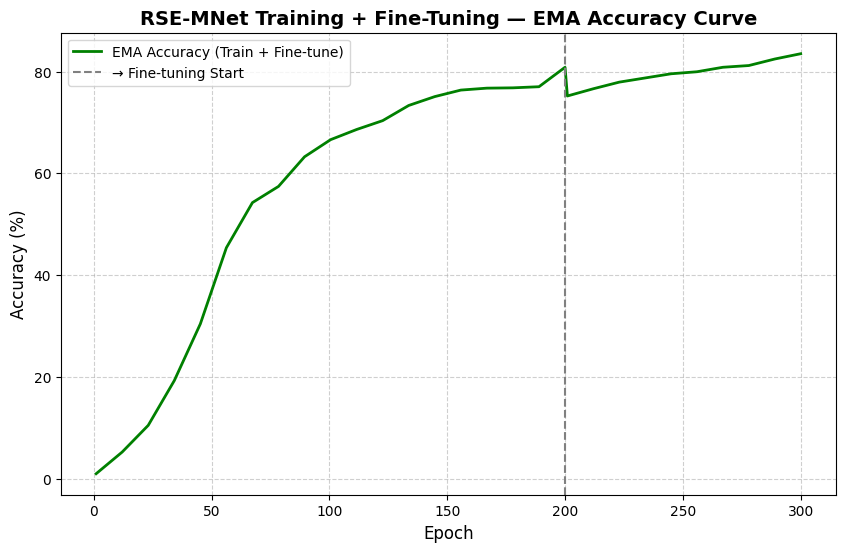

 Total Epochs Combined: 29
 Final EMA Accuracy: 83.50%


In [ ]:
import matplotlib.pyplot as plt
import numpy as np


# MANUAL DATA


# --- Training Phase (200 epochs) ---
train_epochs = list(range(1, 201))
train_ema = [
    1.02, 5.28, 10.52, 19.3, 30.44, 45.4, 54.26, 57.44, 63.26, 66.62,
    68.62, 70.36, 73.34, 75.08, 76.36, 76.74, 76.80, 77.02, 80.84
]  # key EMA values

train_epochs = np.linspace(1, 200, len(train_ema))

# Fine-tuning Phase (100 epochs)
fine_epochs = list(range(1, 101))
fine_ema = [
    75.20, 76.62, 77.92, 78.74, 79.56, 79.96, 80.84, 81.18, 82.46, 83.50
]  # from  fine-tune log
fine_epochs = np.linspace(201, 300, len(fine_ema))


# Combine both phases

all_epochs = np.concatenate([train_epochs, fine_epochs])
all_ema = np.concatenate([train_ema, fine_ema])

# Plot the graph

plt.figure(figsize=(10,6))
plt.plot(all_epochs, all_ema, color='green', linewidth=2, label='EMA Accuracy (Train + Fine-tune)')
plt.axvline(x=200, color='gray', linestyle='--', label='→ Fine-tuning Start')

plt.title("RSE-MNet Training + Fine-Tuning — EMA Accuracy Curve", fontsize=14, fontweight='bold')
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Accuracy (%)", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f" Total Epochs Combined: {len(all_epochs)}")
print(f" Final EMA Accuracy: {all_ema[-1]:.2f}%")


STEP 1: Load Trained Model (Best EMA)

In [ ]:

# STEP 6: Load Best Fine-Tuned EMA Model for Evaluation


import torch, os

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

#  Define the model architecture
model = RSE_MNet_Strong(num_classes=100).to(device)

#  Path to the best fine-tuned EMA model
BEST_EMA_PATH = os.path.join(PROJECT_DIR, "models_finetune_boost", "rse_best_ema.pth")
assert os.path.exists(BEST_EMA_PATH), f" Best EMA checkpoint not found at {BEST_EMA_PATH}"

#  Load EMA weights
state_dict = torch.load(BEST_EMA_PATH, map_location=device)
model.load_state_dict(state_dict)
model.eval()

print(" Best Fine-Tuned EMA model loaded successfully.")
print("Ready for testing, validation, or custom inference.")


Using device: cuda
 Best Fine-Tuned EMA model loaded successfully.
Ready for testing, validation, or custom inference.


In [ ]:
import torch
import torch.nn as nn
from tqdm import tqdm

# Define the same loss used in training (important!)
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

def evaluate(model_eval, loader, name="Val"):
    model_eval.eval()
    loss_sum, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, lbls in tqdm(loader, desc=name, leave=False):
            imgs, lbls = imgs.to(next(model_eval.parameters()).device), lbls.to(next(model_eval.parameters()).device)
            preds = model_eval(imgs)
            loss = criterion(preds, lbls)
            loss_sum += loss.item() * imgs.size(0)
            correct += (preds.argmax(1) == lbls).sum().item()
            total += lbls.size(0)
    return loss_sum / total, correct / total


#Test Accuracy

In [ ]:
test_loss, test_acc = evaluate(model, test_loader, "Test")
print(f"🏁 Loaded EMA Model — Test Accuracy: {test_acc*100:.2f}%")


🏁 Loaded EMA Model — Test Accuracy: 80.78%


#STEP 2: Run Model on Test Set and Store Predictions

In [ ]:


import numpy as np
from tqdm import tqdm

all_preds, all_labels = [], []

model.eval()
with torch.no_grad():
    for imgs, lbls in tqdm(test_loader, desc="Running Evaluation"):
        imgs, lbls = imgs.to(device), lbls.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(lbls.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
print("✅ Predictions collected for all test samples.")


Running Evaluation: 100%|██████████| 79/79 [00:12<00:00,  6.11it/s]

✅ Predictions collected for all test samples.


#STEP 3: Classification Report (Precision, Recall, F1)

In [ ]:

from sklearn.metrics import classification_report

print("📋 Classification Report:")
print(classification_report(all_labels, all_preds, digits=4))


📋 Classification Report:
              precision    recall  f1-score   support

           0     0.8824    0.9000    0.8911       100
           1     0.9300    0.9300    0.9300       100
           2     0.6176    0.6300    0.6238       100
           3     0.7849    0.7300    0.7565       100
           4     0.6435    0.7400    0.6884       100
           5     0.8454    0.8200    0.8325       100
           6     0.8333    0.8500    0.8416       100
           7     0.8421    0.8000    0.8205       100
           8     0.9787    0.9200    0.9485       100
           9     0.8304    0.9300    0.8774       100
          10     0.7342    0.5800    0.6480       100
          11     0.5300    0.5300    0.5300       100
          12     0.9158    0.8700    0.8923       100
          13     0.8218    0.8300    0.8259       100
          14     0.7925    0.8400    0.8155       100
          15     0.8990    0.8900    0.8945       100
          16     0.8261    0.7600    0.7917       100
  

#STEP 4: Confusion Matrix

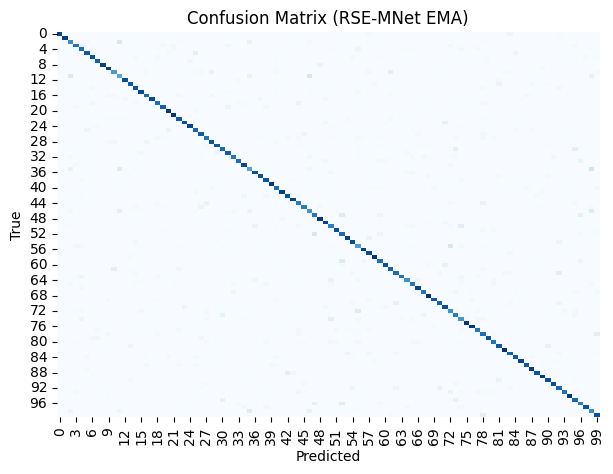

In [ ]:

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, cmap="Blues", cbar=False)
plt.title("Confusion Matrix (RSE-MNet EMA)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


# STEP 5: Visualize Random Predictions

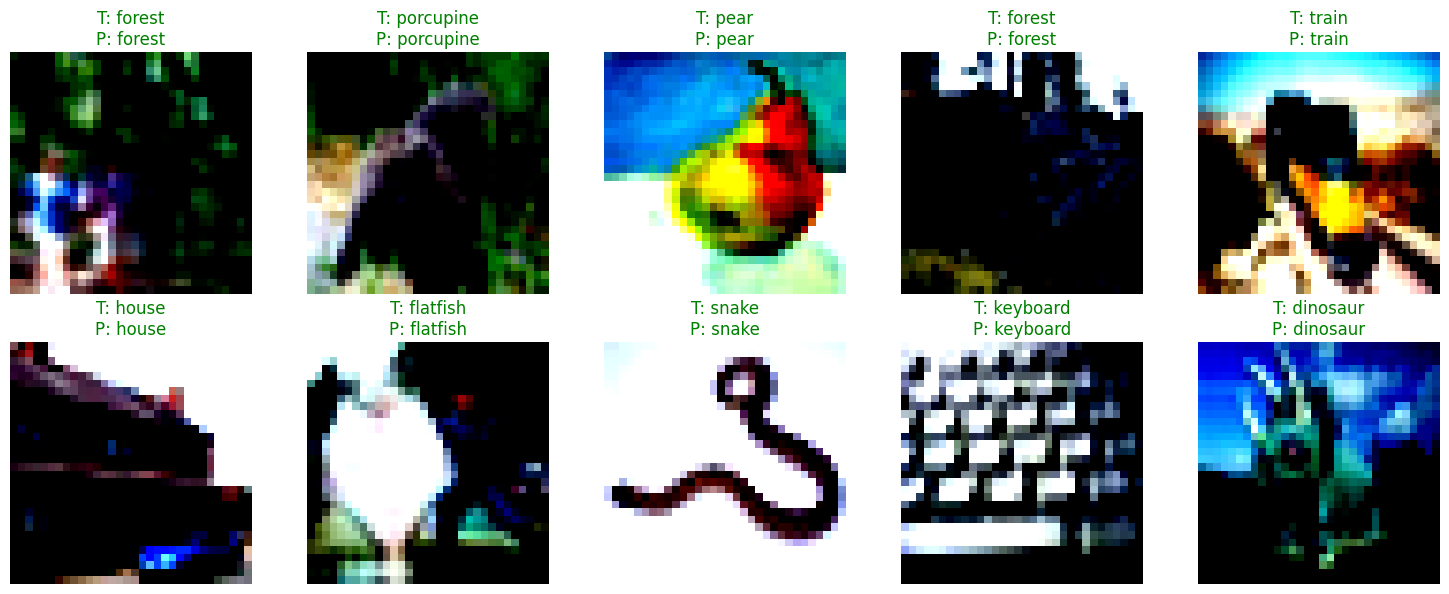

In [ ]:

import random
import numpy as np

classes = test_loader.dataset.classes if hasattr(test_loader.dataset, "classes") else [str(i) for i in range(100)]

images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    preds = model(images).argmax(1)

plt.figure(figsize=(15, 6))
for i in range(10):
    idx = random.randint(0, len(images)-1)
    img = images[idx].permute(1, 2, 0).cpu().numpy()
    true_label = classes[labels[idx].item()]
    pred_label = classes[preds[idx].item()]
    color = "green" if true_label == pred_label else "red"
    plt.subplot(2, 5, i+1)
    plt.imshow(np.clip(img, 0, 1))
    plt.title(f"T: {true_label}\nP: {pred_label}", color=color)
    plt.axis("off")

plt.tight_layout()
plt.show()


#STEP 6: Visualize Random Predictions

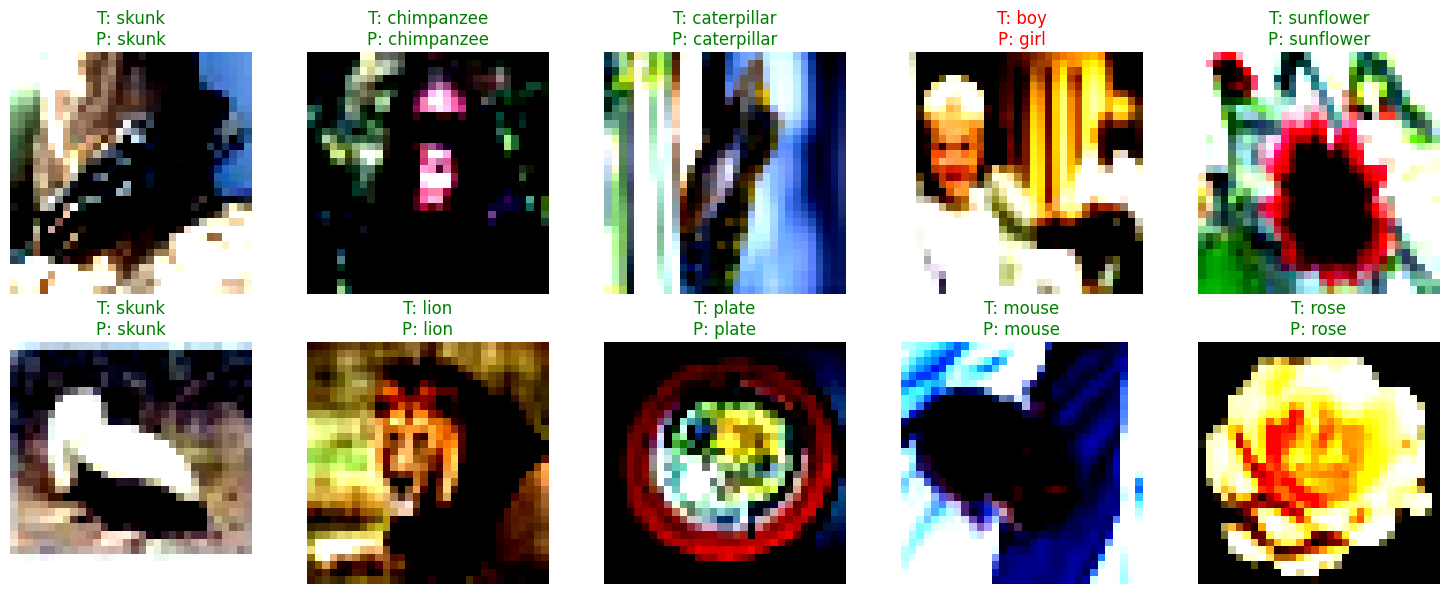

In [ ]:

import random
import numpy as np

classes = test_loader.dataset.classes if hasattr(test_loader.dataset, "classes") else [str(i) for i in range(100)]

images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    preds = model(images).argmax(1)

plt.figure(figsize=(15, 6))
for i in range(10):
    idx = random.randint(0, len(images)-1)
    img = images[idx].permute(1, 2, 0).cpu().numpy()
    true_label = classes[labels[idx].item()]
    pred_label = classes[preds[idx].item()]
    color = "green" if true_label == pred_label else "red"
    plt.subplot(2, 5, i+1)
    plt.imshow(np.clip(img, 0, 1))
    plt.title(f"T: {true_label}\nP: {pred_label}", color=color)
    plt.axis("off")

plt.tight_layout()
plt.show()
